# Campaign learning curves — CNN vs v2 (full transformer)
Per-L convergence traces. L=4 has ED (energy / rel-err / V-score); L=6–12 are NQS-only (energy / V-score). Recipe: v2 = 3e-4 diag_shift + cosine lr→0.25×, 200 steps. json+numpy+matplotlib.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.grid":True,"grid.alpha":0.3})
NQS,ED = Path("../results/nqs"),Path("../results/ed")
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
LABEL={"cnn":"CNN","v2c8":"v2 d=8","v2c16":"v2 d=16"}
COLOR={"cnn":"C0","v2c8":"C1","v2c16":"C2"}
real=lambda xs: np.array([complex(x).real for x in xs])

def load(L,hz,arm):
    # CNN files: L4 uses _cnn suffix (2-dec); L>=6 phase-transition sweep is bare 3-dec.
    if arm=="cnn":
        p = NQS/f"G-equiv_1_L4_hx0.00_hz{hz:.2f}_cnn.json" if L==4 else NQS/f"G-equiv_1_L{L}_hx0.00_hz{hz:.3f}.json"
    else:
        p = NQS/f"G-equiv_1_L{L}_hx0.00_hz{hz:.2f}_{arm}.json"
    return json.load(open(p)) if p.exists() else None
edE0=lambda hz: json.load(open(ED/f"ed_L4_hx0.00_hz{hz:.2f}.json"))["E0"]

In [2]:
# --- knobs ---
HZ_L4  = 0.30   # L=4 field to inspect (0.10..0.30; ED available)
HZ_BIG = 0.30   # L>=6 field to inspect (0.25 or 0.30)

## 1. L=4 — energy, relative error, V-score  (CNN vs v2 d=8)

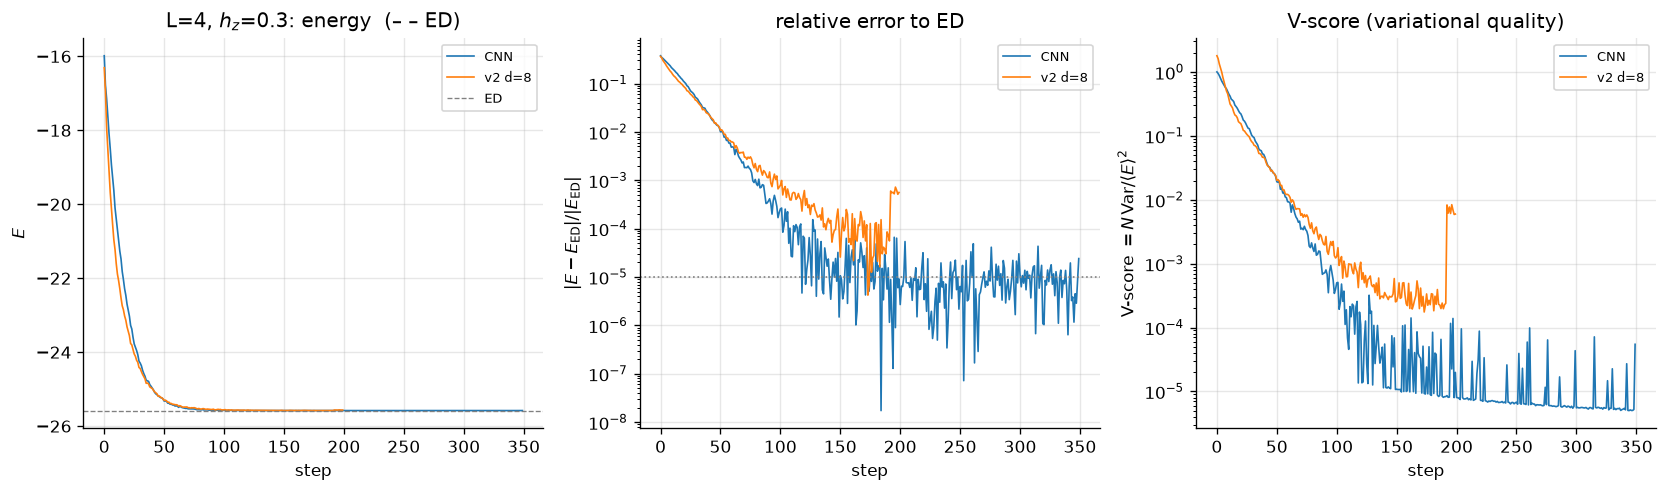

In [3]:
# L=4: energy, relative error, and V-score vs step. CNN vs v2 (d=8, the recipe run). ED available.
# (v2 curves may end before CNN if a run was walltime-limited.)
fig,ax=plt.subplots(1,3,figsize=(14,4.2))
E0=edE0(HZ_L4)
for arm in ("cnn","v2c8"):
    d=load(4,HZ_L4,arm)
    if d is None: continue
    E=real(d["energy"]); s=np.arange(len(E)); V=real(d["Vscore"])
    ax[0].plot(s,E,color=COLOR[arm],lw=1,label=LABEL[arm])
    ax[1].plot(s,np.abs(E-E0)/abs(E0),color=COLOR[arm],lw=1,label=LABEL[arm])
    ax[2].plot(s,V,color=COLOR[arm],lw=1,label=LABEL[arm])
ax[0].axhline(E0,color="grey",ls="--",lw=0.8,label="ED")
ax[0].set(xlabel="step",ylabel="$E$",title=f"L=4, $h_z$={HZ_L4}: energy  (– – ED)"); ax[0].legend(fontsize=8)
ax[1].axhline(1e-5,color="grey",ls=":",lw=1)
ax[1].set(xlabel="step",ylabel=r"$|E-E_{\mathrm{ED}}|/|E_{\mathrm{ED}}|$",yscale="log",title="relative error to ED"); ax[1].legend(fontsize=8)
ax[2].set(xlabel="step",ylabel=r"V-score $=N\,\mathrm{Var}/\langle E\rangle^2$",yscale="log",title="V-score (variational quality)"); ax[2].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG/"06_L4_curves.png",dpi=200,bbox_inches="tight")

## 2. L=6,8,10,12 — energy & V-score  (CNN vs v2 d=8, d=16)
Watch the V-score column: CNN settles ~1e-5; v2 plateaus 1e-3–1e-2 and jitters (the instability).

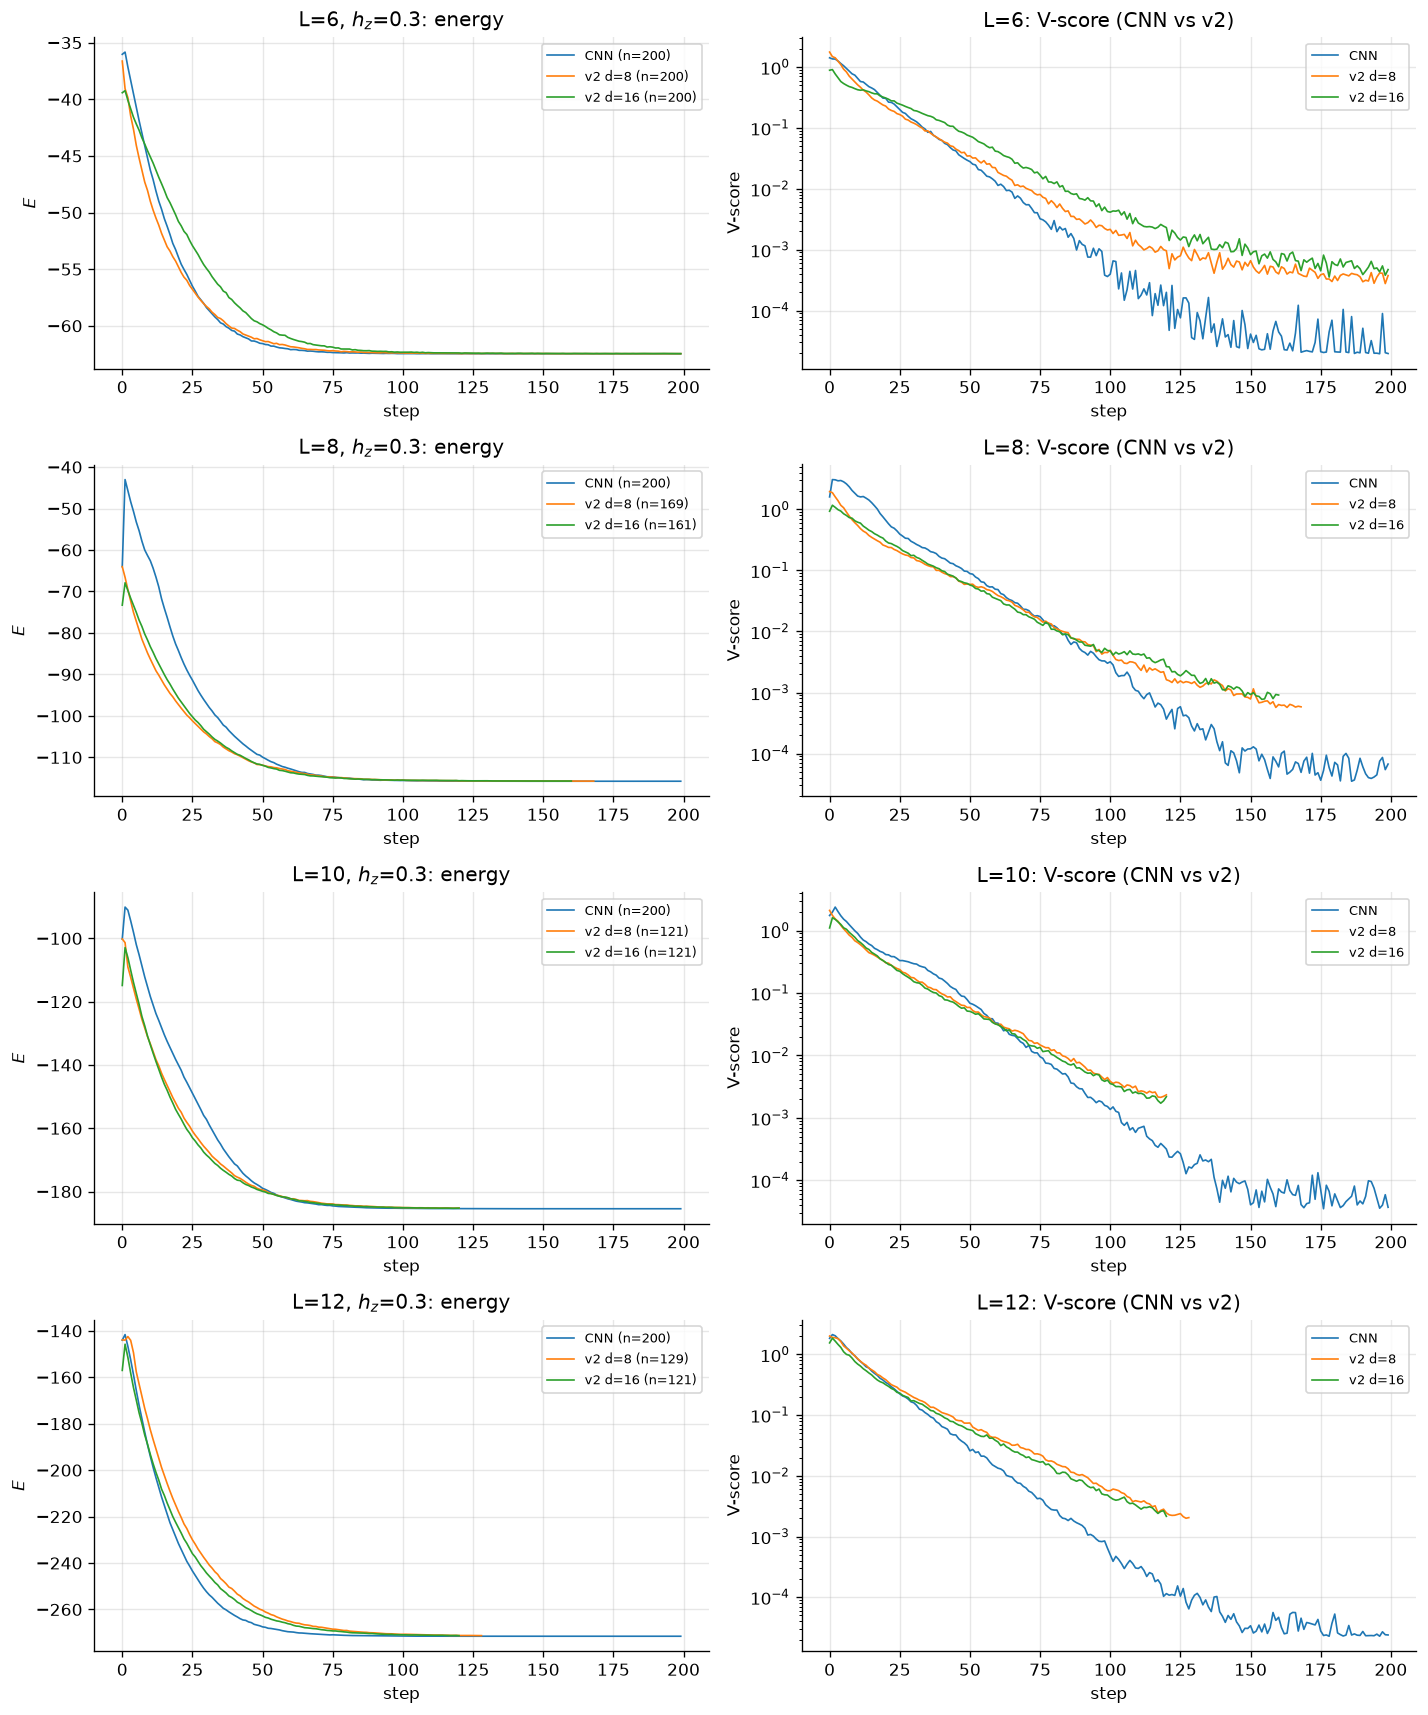

In [4]:
# L=6,8,10,12: energy and V-score vs step. CNN vs v2 (d=8, d=16). No ED at these sizes,
# so no rel-err panel. Note several v2 runs are walltime-limited (curves end < 200 steps).
Ls=[6,8,10,12]
fig,ax=plt.subplots(len(Ls),2,figsize=(12,3.6*len(Ls)))
for r,L in enumerate(Ls):
    for arm in ("cnn","v2c8","v2c16"):
        d=load(L,HZ_BIG,arm)
        if d is None: continue
        E=real(d["energy"]); s=np.arange(len(E)); V=real(d["Vscore"])
        ax[r,0].plot(s,E,color=COLOR[arm],lw=1,label=f"{LABEL[arm]} (n={len(E)})")
        ax[r,1].plot(s,V,color=COLOR[arm],lw=1,label=LABEL[arm])
    ax[r,0].set(xlabel="step",ylabel="$E$",title=f"L={L}, $h_z$={HZ_BIG}: energy"); ax[r,0].legend(fontsize=8)
    ax[r,1].set(xlabel="step",ylabel="V-score",yscale="log",title=f"L={L}: V-score (CNN vs v2)"); ax[r,1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG/"06_L6-12_curves.png",dpi=200,bbox_inches="tight")